# Introduction to Generative AI: Autoencoders, VAEs, and GANs
## A learning-first notebook with intuition, analogies, and working code

This notebook focuses on **three foundational generative model families**:

- **Autoencoders (AEs)**
- **Variational Autoencoders (VAEs)**
- **Generative Adversarial Networks (GANs)**

We will keep the examples approachable by using **MNIST handwritten digits** and by pairing the code with **real-world analogies**.

### Big idea

A **discriminative model** is like a judge: it looks at an input and decides **what class it belongs to**.

A **generative model** is like an artist, compression engine, or simulator: it tries to learn **how the data itself is structured**, so it can **reconstruct**, **sample**, or **generate** new examples.

### What this notebook does

For each model family, we will:

1. build intuition with simple language and analogies,
2. implement a **small example**,
3. visualize what the model learned,
4. and then connect it to a **stronger library-style architecture** used in official tutorials.

### Why MNIST?

MNIST is not the most exciting dataset, but it is ideal for learning because it is:

- easy to visualize,
- fast to train on CPU,
- small enough for classroom experiments,
- and rich enough to show the difference between reconstruction and generation.

---
## Learning outcomes

By the end, you should be able to:

1. explain the difference between **discriminative** and **generative** modeling,
2. describe how an **autoencoder** compresses and reconstructs data,
3. explain why a **VAE** learns a distribution instead of only a single code,
4. describe the adversarial game between a **GAN generator** and **discriminator**,
5. connect these ideas to real applications such as denoising, anomaly detection, and image synthesis,
6. and know where to go next in official TensorFlow/Keras and PyTorch resources.

## 1. Generative vs. Discriminative Models

A simple analogy:

- A **discriminative model** is like a student taking a multiple-choice test.  
  It learns how to choose the correct label.

- A **generative model** is like a student asked to **draw a new example** that looks like the training data.  
  It must learn what the data *looks like* internally.

### Examples

| Type | Main question | Example tasks |
|---|---|---|
| Discriminative | “What label fits this input?” | classify spam vs. not spam, cat vs. dog |
| Generative | “How could data like this be produced?” | reconstruct images, sample new digits, synthesize faces |

### The three families in this notebook

| Model | Core idea | Easy analogy |
|---|---|---|
| Autoencoder | compress and reconstruct | zip file + unzip file |
| VAE | learn a smooth latent distribution | a map of neighborhoods, not one exact address |
| GAN | generator fools a discriminator | counterfeiter vs. detective |

## 2. Setup and Data

We will use **MNIST digits**.  
To keep training classroom-friendly, the notebook uses a **subset** by default.

You can increase the subset size later if you want sharper results.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1776455900.635769  181832 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776455900.638056  181832 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776455900.712404  181832 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776455902.250030  181832 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow version: 2.21.0
GPU devices: []


E0000 00:00:1776455902.802557  181832 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
I0000 00:00:1776455902.802580  181832 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1776455902.802582  181832 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: lap
I0000 00:00:1776455902.802585  181832 cuda_diagnostics.cc:183] hostname: lap
I0000 00:00:1776455902.802643  181832 cuda_diagnostics.cc:190] libcuda reported version is: 580.126.9
I0000 00:00:1776455902.802653  181832 cuda_diagnostics.cc:194] kernel reported version is: 580.126.9
I0000 00:00:1776455902.802654  181832 cuda_diagnostics.cc:284] kernel version seems to match DSO: 580.126.9


In [2]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] for autoencoder / VAE
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Smaller subset for faster experimentation
TRAIN_SAMPLES = 12000
TEST_SAMPLES = 2000

x_train = x_train[:TRAIN_SAMPLES]
y_train = y_train[:TRAIN_SAMPLES]
x_test = x_test[:TEST_SAMPLES]
y_test = y_test[:TEST_SAMPLES]

# Shapes for different model types
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

x_train_img = np.expand_dims(x_train, -1)
x_test_img = np.expand_dims(x_test, -1)

# GAN convention often uses [-1, 1]
x_train_gan = (x_train_img * 2.0) - 1.0

print("x_train_img:", x_train_img.shape)
print("x_train_flat:", x_train_flat.shape)
print("x_train_gan :", x_train_gan.shape)

x_train_img: (12000, 28, 28, 1)
x_train_flat: (12000, 784)
x_train_gan : (12000, 28, 28, 1)


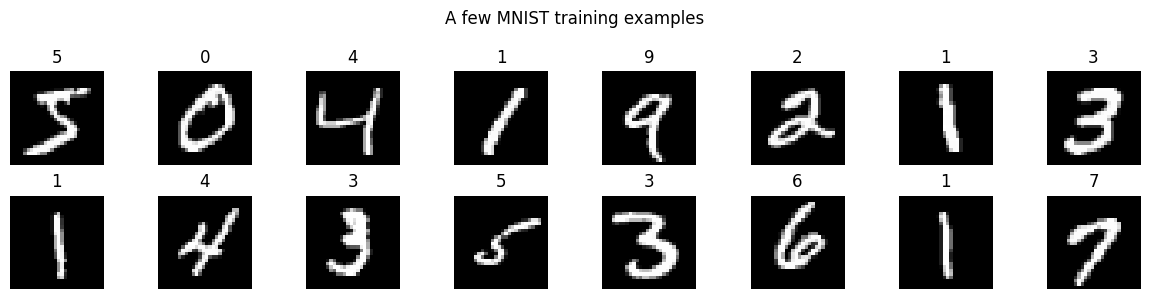

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for ax, img, label in zip(axes.ravel(), x_train[:16], y_train[:16]):
    ax.imshow(img, cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.suptitle("A few MNIST training examples")
plt.tight_layout()
plt.show()

## 3. A quick roadmap: AE vs. VAE vs. GAN

| Model | What goes in? | What comes out? | What is optimized? | Typical strength |
|---|---|---|---|---|
| Autoencoder | real input image | reconstruction of same image | reconstruction loss | compression, denoising, anomaly detection |
| VAE | real input image | reconstruction + latent distribution | reconstruction + KL divergence | smooth latent space, controllable sampling |
| GAN | random noise | brand-new synthetic image | adversarial loss | sharp, realistic-looking samples |

A practical way to remember them:

- **Autoencoder**: “Can I rebuild what I saw?”
- **VAE**: “Can I rebuild it *and* learn a meaningful latent map?”
- **GAN**: “Can I make new samples that look real enough to fool a critic?”

# Part A — Autoencoders

## 4. Intuition: what is an autoencoder?

An autoencoder has two main parts:

- **Encoder**: compresses the input into a smaller representation
- **Decoder**: expands that compressed representation back into an output

### Everyday analogy: a zip file

Imagine you want to email a large folder:

1. you **compress** it into a smaller `.zip` file,
2. someone later **unzips** it,
3. and hopes to recover the important content.

That is exactly the spirit of an autoencoder.

### Why the bottleneck matters

If the compressed code is **smaller than the original input**, the model is forced to keep only the most important information.

That bottleneck can help it learn:

- structure,
- patterns,
- and redundancy in the data.

### Important warning

A perfect reconstruction is **not always the main goal**.  
Sometimes the bottleneck representation is the valuable part.

## 5. Encoder, decoder, bottleneck, and reconstruction loss

Let the input be **x**.

- Encoder: **z = encoder(x)**
- Decoder: **x_hat = decoder(z)**

The model tries to make **x_hat** close to **x**.

### Common reconstruction losses

- **Mean squared error (MSE)**: common when the output is continuous
- **Binary cross-entropy (BCE)**: common when pixel values are scaled to [0, 1]

For MNIST, BCE is often a good simple choice because the images are grayscale and close to binary structure.

### Real-world use cases of autoencoders

- denoising noisy images,
- dimensionality reduction,
- anomaly detection,
- learning compact embeddings.

## 6. A tiny dense autoencoder (simple version)

We will start with a **very small dense autoencoder**.

Why start small?

Because it makes the structure easy to understand:

- input image = 784 numbers,
- bottleneck = 2 numbers,
- output image = 784 numbers again.

A 2D bottleneck is intentionally tiny.  
It will not reconstruct perfectly, but it is great for visualization.

In [4]:
latent_dim_ae = 2

encoder_ae = keras.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(latent_dim_ae, name="latent_code"),
    ],
    name="encoder_ae",
)

decoder_ae = keras.Sequential(
    [
        layers.Input(shape=(latent_dim_ae,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(784, activation="sigmoid"),
    ],
    name="decoder_ae",
)

input_img = keras.Input(shape=(784,))
encoded = encoder_ae(input_img)
decoded = decoder_ae(encoded)
autoencoder = keras.Model(input_img, decoded, name="dense_autoencoder")

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

encoder_ae.summary()
decoder_ae.summary()
autoencoder.summary()

Model: "encoder_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_code (Dense)             │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,738 (393.51 KB)

 Trainable params: 100,738 (393.51 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_ae (Sequential)         │ (None, 2)              │       100,738 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_ae (Sequential)         │ (None, 784)            │       101,520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,258 (790.07 KB)

 Trainable params: 202,258 (790.07 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
start = time.perf_counter()

history_ae = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=8,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat),
    verbose=0,
)

ae_seconds = time.perf_counter() - start
print(f"Dense autoencoder training time: {ae_seconds:.2f} seconds")

Dense autoencoder training time: 3.10 seconds


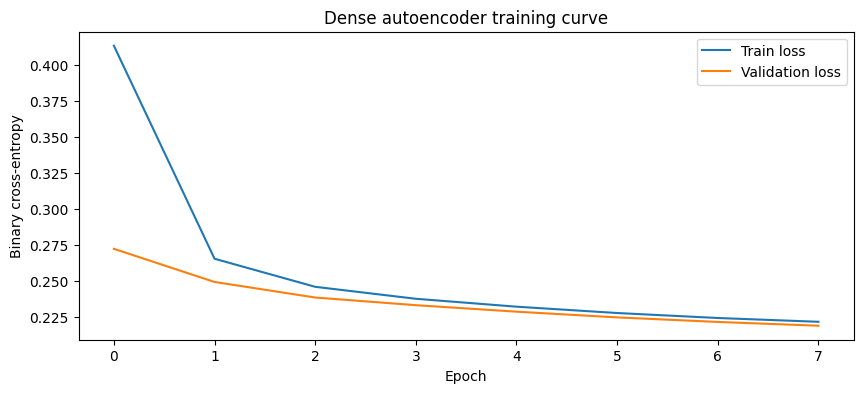

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(history_ae.history["loss"], label="Train loss")
plt.plot(history_ae.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Dense autoencoder training curve")
plt.legend()
plt.show()

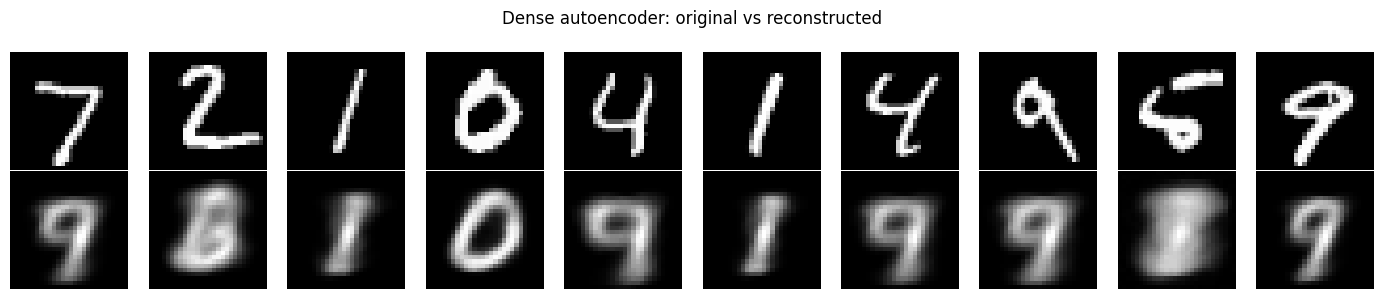

In [7]:
reconstructed_ae = autoencoder.predict(x_test_flat[:10], verbose=0).reshape(-1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    axes[0, i].imshow(x_test[i], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructed_ae[i], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Recon", fontsize=12)
plt.suptitle("Dense autoencoder: original vs reconstructed")
plt.tight_layout()
plt.show()

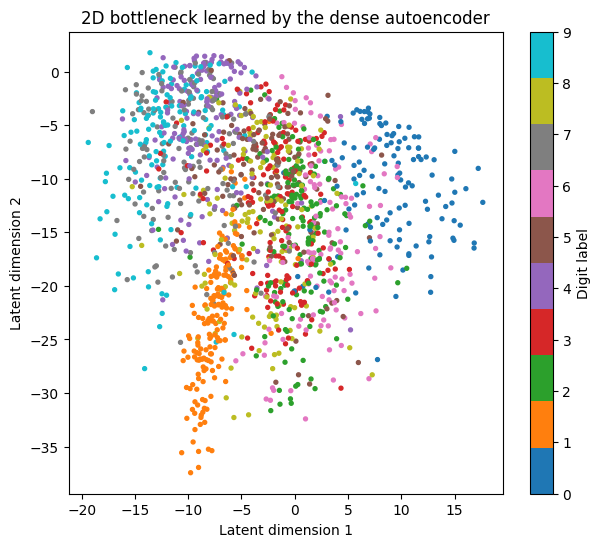

In [8]:
z_test = encoder_ae.predict(x_test_flat[:1500], verbose=0)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(z_test[:, 0], z_test[:, 1], c=y_test[:1500], s=8, cmap="tab10")
plt.colorbar(scatter, label="Digit label")
plt.title("2D bottleneck learned by the dense autoencoder")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.show()

### What to notice

- The reconstructions are recognizable but blurry.
- The 2D bottleneck forces the model to compress a lot of information.
- Similar digits often cluster near each other in latent space.

This is one reason autoencoders are useful:  
they can learn a compact representation without being told class labels.

### Easier mental picture

Think of the bottleneck as a **tiny summary card**.  
The encoder must decide what to write on that card so the decoder can rebuild the image later.

## 7. A stronger library-style autoencoder: convolutional denoising autoencoder

The dense model above is useful for understanding the idea.  
But images usually benefit from **convolutional layers**, because images have local spatial structure.

### Real-world analogy

A convolutional autoencoder is like a photo restoration tool:

- it first learns **local patterns** such as strokes and edges,
- then it uses those patterns to rebuild a cleaner version.

This is closer to how practical image autoencoders are often built.

In [9]:
def add_noise(images, noise_factor=0.35):
    noisy = images + noise_factor * np.random.normal(size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype("float32")

x_train_noisy = add_noise(x_train_img)
x_test_noisy = add_noise(x_test_img)

conv_autoencoder = keras.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu", padding="same", strides=2),
        layers.Conv2D(16, 3, activation="relu", padding="same", strides=2),
        layers.Conv2DTranspose(16, 3, activation="relu", padding="same", strides=2),
        layers.Conv2DTranspose(32, 3, activation="relu", padding="same", strides=2),
        layers.Conv2D(1, 3, activation="sigmoid", padding="same"),
    ],
    name="conv_denoising_autoencoder",
)

conv_autoencoder.compile(optimizer="adam", loss="mse")
conv_autoencoder.summary()

Model: "conv_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
start = time.perf_counter()

history_conv_ae = conv_autoencoder.fit(
    x_train_noisy,
    x_train_img,
    epochs=4,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_img),
    verbose=0,
)

conv_ae_seconds = time.perf_counter() - start
print(f"Conv autoencoder training time: {conv_ae_seconds:.2f} seconds")

Conv autoencoder training time: 7.83 seconds


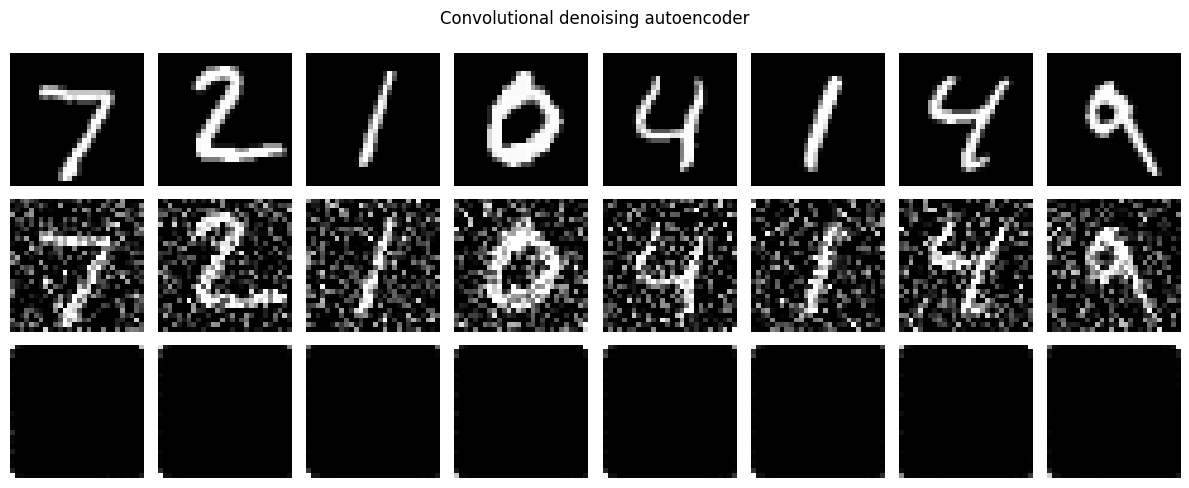

In [11]:
decoded_imgs = conv_autoencoder.predict(x_test_noisy[:8], verbose=0)

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for i in range(8):
    axes[0, i].imshow(x_test_img[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[2, i].imshow(decoded_imgs[i].squeeze(), cmap="gray")
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Clean", fontsize=12)
axes[1, 0].set_ylabel("Noisy", fontsize=12)
axes[2, 0].set_ylabel("Recon", fontsize=12)
plt.suptitle("Convolutional denoising autoencoder")
plt.tight_layout()
plt.show()

### Learn more

- TensorFlow autoencoder tutorial: https://www.tensorflow.org/tutorials/generative/autoencoder
- Keras convolutional autoencoder example: https://keras.io/examples/vision/autoencoder/
- Hinton et al., *Reducing the Dimensionality of Data with Neural Networks*: https://www.cs.toronto.edu/~hinton/absps/science.pdf

### Key takeaway

The **simple version** helped us understand the core idea.  
The **convolutional version** is more realistic for image data.

# Part B — Variational Autoencoders (VAEs)

## 8. Why not stop at a plain autoencoder?

A regular autoencoder can learn useful compressed codes, but its latent space is not guaranteed to be:

- smooth,
- continuous,
- or easy to sample from.

You might get nice reconstructions, yet random points in latent space may decode into nonsense.

A **VAE** fixes this by learning a **distribution** in latent space.

## 9. Intuition: what makes a VAE different?

### Everyday analogy: a neighborhood map, not a single address

A regular autoencoder might memorize one exact address for each example.

A VAE instead learns something like:

- the **center** of a neighborhood (**mu**),
- and how spread out that neighborhood is (**sigma**).

That means nearby latent points are more likely to decode into similar, meaningful outputs.

### Why this matters

If the latent space is smooth, then you can:

- sample new points,
- interpolate between examples,
- and generate new data more reliably.

## 10. The reparameterization trick in plain English

The encoder does **not** output one fixed latent point.

Instead, it outputs:

- **mu**: the mean
- **log_var**: the log variance

Then we sample:

\[
z = \mu + \sigma \odot \epsilon
\]

where:

- \(\epsilon \sim \mathcal{N}(0, 1)\)
- \(\sigma = \exp(0.5 \cdot \text{log\_var})\)

### Easy analogy

Imagine baking cookies:

- **mu** is the recipe's target amount,
- **sigma** is how much variation you allow,
- **epsilon** is the random wiggle,
- and **z** is the final sampled cookie.

This trick lets the model stay differentiable during training.

## 11. VAE loss: two goals at once

A VAE optimizes a **balancing act**:

1. **Reconstruction loss**  
   “Can I rebuild the input well?”

2. **KL divergence**  
   “Is my latent space staying close to a simple, smooth distribution?”

### Plain-language version

- Reconstruction loss rewards **accuracy**
- KL divergence rewards **order and smoothness**

If you only optimize reconstruction, the latent space can become messy.

If you only optimize KL divergence, the model becomes too generic and reconstructs poorly.

A good VAE balances both.

In [12]:
latent_dim_vae = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = keras.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(encoder_inputs)
z_mean = layers.Dense(latent_dim_vae, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim_vae, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder_vae = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder_vae")

latent_inputs = keras.Input(shape=(latent_dim_vae,))
x = layers.Dense(256, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(784, activation="sigmoid")(x)
decoder_vae = keras.Model(latent_inputs, decoder_outputs, name="decoder_vae")

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=-1,
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1,
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = VAE(encoder_vae, decoder_vae, name="dense_vae")
vae.compile(optimizer=keras.optimizers.Adam())
encoder_vae.summary()
decoder_vae.summary()

Model: "encoder_vae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    200,960 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 201,988 (789.02 KB)

 Trainable params: 201,988 (789.02 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder_vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,256 (790.06 KB)

 Trainable params: 202,256 (790.06 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
start = time.perf_counter()

history_vae = vae.fit(
    x_train_flat,
    epochs=10,
    batch_size=256,
    verbose=0,
)

vae_seconds = time.perf_counter() - start
print(f"Dense VAE training time: {vae_seconds:.2f} seconds")

Dense VAE training time: 3.65 seconds


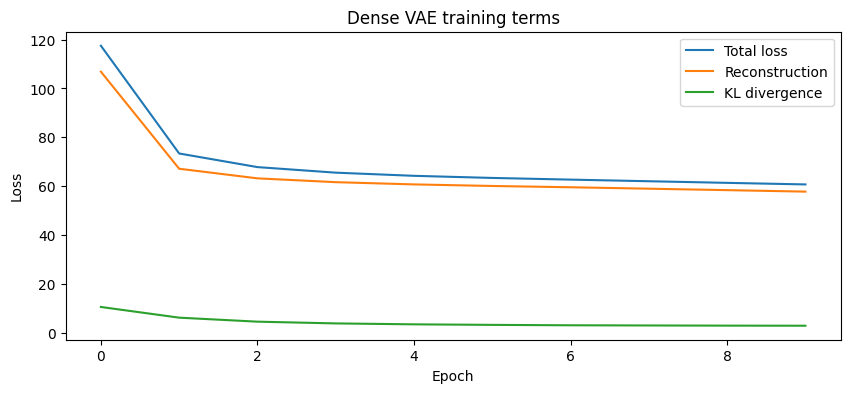

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(history_vae.history["loss"], label="Total loss")
plt.plot(history_vae.history["reconstruction_loss"], label="Reconstruction")
plt.plot(history_vae.history["kl_loss"], label="KL divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dense VAE training terms")
plt.legend()
plt.show()

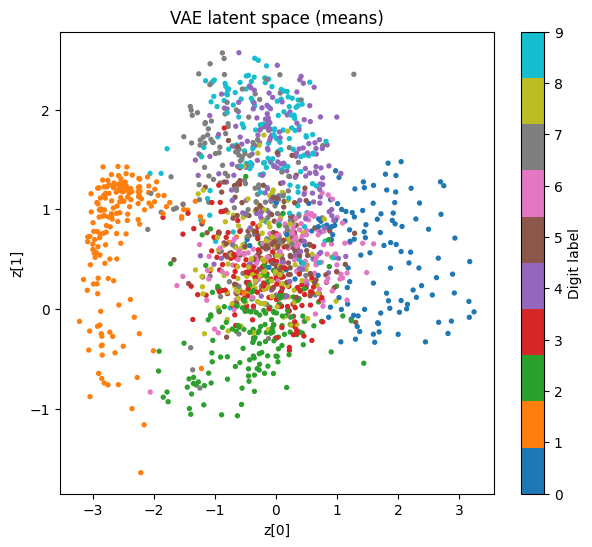

In [15]:
z_mean_test, z_log_var_test, z_test = encoder_vae.predict(x_test_flat[:1500], verbose=0)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test[:1500], s=8, cmap="tab10")
plt.colorbar(scatter, label="Digit label")
plt.title("VAE latent space (means)")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.show()

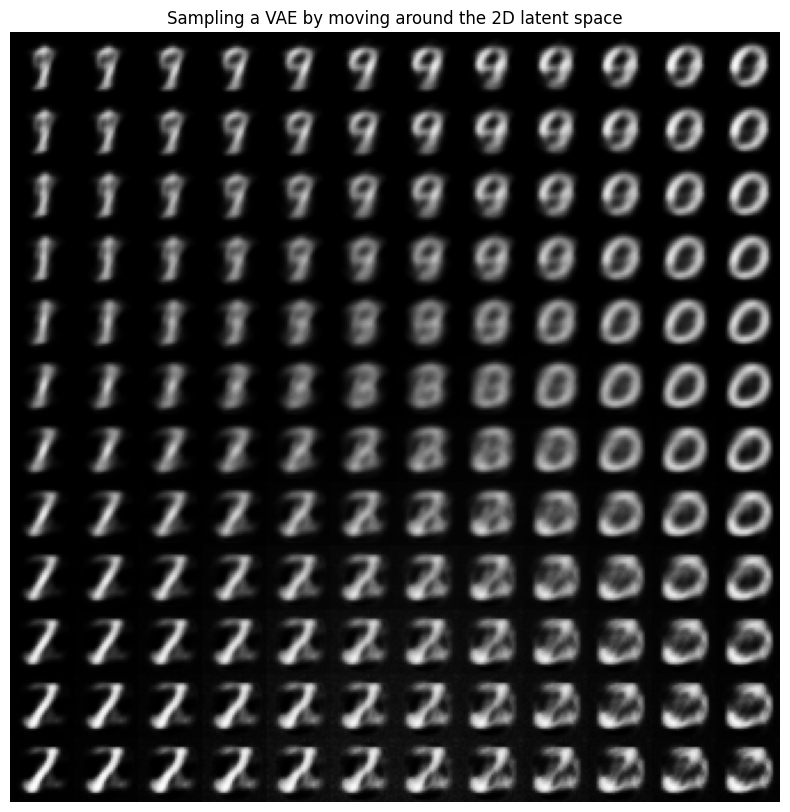

In [16]:
# Visualize samples across the 2D latent space
n = 12
grid_x = np.linspace(-2.0, 2.0, n)
grid_y = np.linspace(-2.0, 2.0, n)[::-1]

figure = np.zeros((28 * n, 28 * n))

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]], dtype=np.float32)
        x_decoded = decoder_vae.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(28, 28)
        figure[i * 28 : (i + 1) * 28, j * 28 : (j + 1) * 28] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.title("Sampling a VAE by moving around the 2D latent space")
plt.axis("off")
plt.show()

### What to notice

- The VAE latent space is more **organized** than a plain autoencoder's bottleneck.
- Nearby points often produce visually related digits.
- That is why VAEs are useful when you care about **sampling** and **interpolation**, not only reconstruction.

### Key mental model

A VAE does not just memorize where one example lives.  
It tries to learn a **smooth map** of where many examples could reasonably live.

## 12. A stronger library-style VAE: convolutional VAE pattern

For image tasks, a practical next step is a **convolutional VAE (CVAE)**.

Why?

Because:

- convolutions handle spatial patterns better,
- the encoder can learn local structure,
- and the decoder can generate images more naturally.

### Learn more

- TensorFlow CVAE tutorial: https://www.tensorflow.org/tutorials/generative/cvae
- Original VAE paper: https://arxiv.org/abs/1312.6114
- Keras generative examples index: https://keras.io/examples/generative/

In [17]:
# Optional: stronger architecture pattern (not trained here)
def build_conv_vae(latent_dim=16):
    encoder_inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="conv_vae_encoder")

    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    decoder_outputs = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)
    decoder = keras.Model(latent_inputs, decoder_outputs, name="conv_vae_decoder")
    return encoder, decoder

conv_vae_encoder, conv_vae_decoder = build_conv_vae()
conv_vae_encoder.summary()
conv_vae_decoder.summary()

Model: "conv_vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      2,064 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      2,064 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 424,480 (1.62 MB)

 Trainable params: 424,480 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

Model: "conv_vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3136)           │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,993 (425.75 KB)

 Trainable params: 108,993 (425.75 KB)

 Non-trainable params: 0 (0.00 B)

# Part C — GANs

## 13. Intuition: what is a GAN?

A GAN has two networks:

- **Generator**: tries to make fake data that looks real
- **Discriminator**: tries to tell real data from fake data

### Everyday analogy: counterfeiter vs. detective

- The **generator** is a counterfeiter making fake banknotes.
- The **discriminator** is a detective trying to catch the fakes.

As training continues:

- the counterfeiter gets better,
- the detective gets sharper,
- and both improve because they are competing.

This is why GAN training is called **adversarial**.

## 14. The adversarial game in plain English

Each training round looks like this:

1. sample real images from the dataset,
2. sample random noise,
3. generator turns noise into fake images,
4. discriminator sees both real and fake images,
5. discriminator learns to classify them correctly,
6. generator learns to fool the discriminator better next time.

### Important difference from autoencoders and VAEs

- Autoencoders and VAEs directly compare outputs to inputs.
- GANs do **not** require a pixel-by-pixel reconstruction target.

That is one reason GANs can generate **sharper-looking** outputs, but also why they can be harder to train.

## 15. A tiny dense GAN (simple version)

We will begin with a **simple dense GAN**.

This is not the best architecture for images, but it makes the generator/discriminator roles easy to understand.

### What goes in and out?

- Input to generator: random noise vector
- Output of generator: fake image
- Input to discriminator: real or fake image
- Output of discriminator: probability that the image is real

In [18]:
latent_dim_gan = 64

generator = keras.Sequential(
    [
        layers.Input(shape=(latent_dim_gan,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(28 * 28, activation="tanh"),
        layers.Reshape((28, 28, 1)),
    ],
    name="generator_dense",
)

discriminator = keras.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),
        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.Dense(128),
        layers.LeakyReLU(0.2),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="discriminator_dense",
)

generator.summary()
discriminator.summary()

Model: "generator_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,832 (948.56 KB)

 Trainable params: 242,832 (948.56 KB)

 Non-trainable params: 0 (0.00 B)

Model: "discriminator_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,985 (914.00 KB)

 Trainable params: 233,985 (914.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
bce = keras.losses.BinaryCrossentropy()

generator_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

train_dataset_gan = tf.data.Dataset.from_tensor_slices(x_train_gan).shuffle(10000).batch(256)

@tf.function
def train_step_gan(real_images):
    batch_size = tf.shape(real_images)[0]
    random_noise = tf.random.normal(shape=(batch_size, latent_dim_gan))

    # Train discriminator
    with tf.GradientTape() as disc_tape:
        fake_images = generator(random_noise, training=True)

        real_preds = discriminator(real_images, training=True)
        fake_preds = discriminator(fake_images, training=True)

        real_labels = tf.ones_like(real_preds)
        fake_labels = tf.zeros_like(fake_preds)

        d_loss_real = bce(real_labels, real_preds)
        d_loss_fake = bce(fake_labels, fake_preds)
        d_loss = d_loss_real + d_loss_fake

    disc_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    # Train generator
    random_noise = tf.random.normal(shape=(batch_size, latent_dim_gan))

    with tf.GradientTape() as gen_tape:
        fake_images = generator(random_noise, training=True)
        fake_preds = discriminator(fake_images, training=True)
        misleading_labels = tf.ones_like(fake_preds)
        g_loss = bce(misleading_labels, fake_preds)

    gen_grads = gen_tape.gradient(g_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))

    return d_loss, g_loss

fixed_seed = tf.random.normal(shape=(16, latent_dim_gan))
gan_snapshots = []
gan_history = {"d_loss": [], "g_loss": []}

start = time.perf_counter()

GAN_EPOCHS = 6
for epoch in range(GAN_EPOCHS):
    d_epoch = []
    g_epoch = []

    for real_batch in train_dataset_gan:
        d_loss, g_loss = train_step_gan(real_batch)
        d_epoch.append(float(d_loss))
        g_epoch.append(float(g_loss))

    gan_history["d_loss"].append(np.mean(d_epoch))
    gan_history["g_loss"].append(np.mean(g_epoch))

    generated = generator(fixed_seed, training=False)
    gan_snapshots.append(generated.numpy())

gan_seconds = time.perf_counter() - start
print(f"Dense GAN training time: {gan_seconds:.2f} seconds")

Dense GAN training time: 3.98 seconds


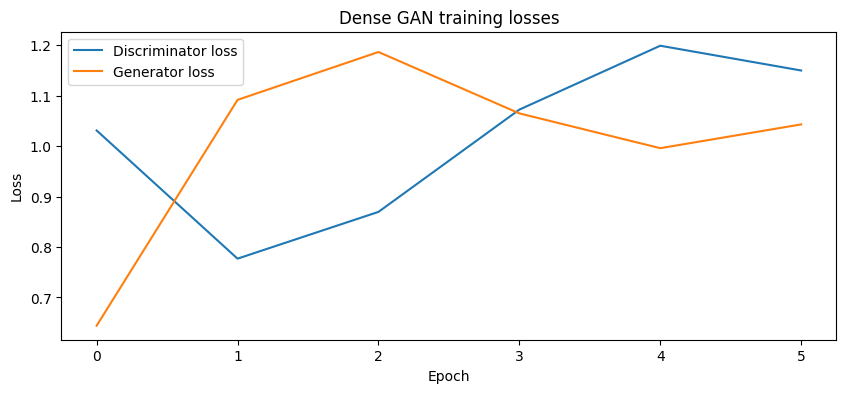

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(gan_history["d_loss"], label="Discriminator loss")
plt.plot(gan_history["g_loss"], label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dense GAN training losses")
plt.legend()
plt.show()

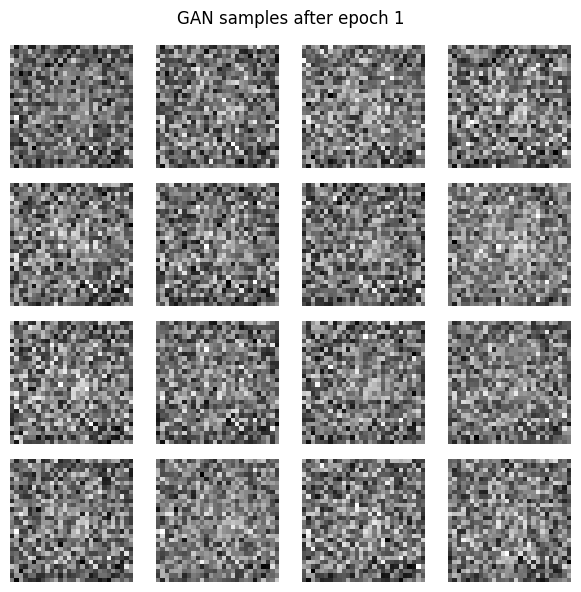

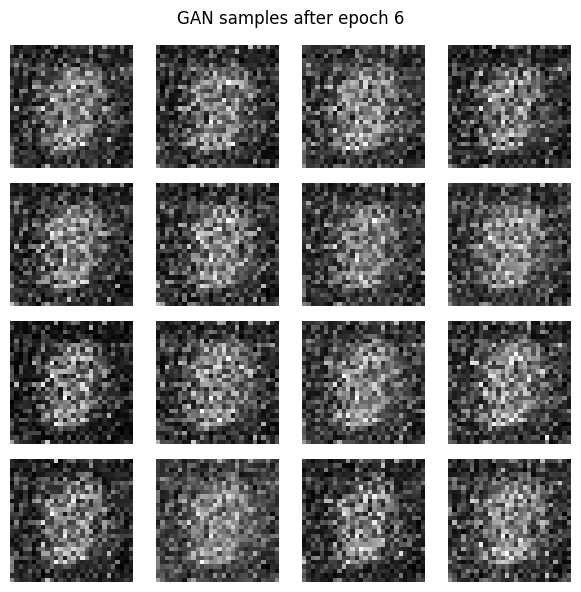

In [21]:
def show_gan_snapshot(snapshot, title):
    imgs = (snapshot + 1.0) / 2.0  # back to [0, 1]
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for ax, img in zip(axes.ravel(), imgs):
        ax.imshow(img.squeeze(), cmap="gray")
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_gan_snapshot(gan_snapshots[0], "GAN samples after epoch 1")
show_gan_snapshot(gan_snapshots[-1], f"GAN samples after epoch {GAN_EPOCHS}")

### What to notice

- Early samples are usually noisy and low quality.
- Later samples often begin to look more digit-like.
- GAN losses do not behave as cleanly as ordinary supervised training curves.

That is normal. GAN training is a game, not a single-objective optimization problem.

### Common GAN difficulty: mode collapse

Sometimes the generator finds one or two outputs that fool the discriminator and repeats them too often.

That problem is called **mode collapse**.

## 16. A stronger library-style GAN: DCGAN pattern

The dense GAN teaches the core adversarial idea.  
For images, a more practical next step is **DCGAN**:

- use convolutional layers in the discriminator,
- use transpose convolutions or upsampling in the generator,
- normalize carefully,
- and train with stable optimizer settings.

### Learn more

- TensorFlow DCGAN tutorial: https://www.tensorflow.org/tutorials/generative/dcgan
- PyTorch DCGAN tutorial: https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
- Original GAN paper: https://arxiv.org/abs/1406.2661

In [22]:
def make_dcgan_generator(latent_dim=100):
    return keras.Sequential(
        [
            layers.Input(shape=(latent_dim,)),
            layers.Dense(7 * 7 * 256, use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Reshape((7, 7, 256)),
            layers.Conv2DTranspose(128, 5, strides=1, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(64, 5, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(1, 5, strides=2, padding="same", use_bias=False, activation="tanh"),
        ],
        name="dcgan_generator",
    )

def make_dcgan_discriminator():
    return keras.Sequential(
        [
            layers.Input(shape=(28, 28, 1)),
            layers.Conv2D(64, 5, strides=2, padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),
            layers.Conv2D(128, 5, strides=2, padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),
            layers.Flatten(),
            layers.Dense(1),
        ],
        name="dcgan_discriminator",
    )

dcgan_gen = make_dcgan_generator()
dcgan_disc = make_dcgan_discriminator()

dcgan_gen.summary()
dcgan_disc.summary()

Model: "dcgan_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Model: "dcgan_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

# Part D — Compare the model families

## 17. Autoencoder vs. VAE vs. GAN in plain language

| Model | Best one-line description | Main strength | Common weakness |
|---|---|---|---|
| Autoencoder | learns to compress and rebuild | simple, useful embeddings, denoising | random latent points may not decode well |
| VAE | learns a smooth latent distribution | principled sampling and interpolation | samples can look blurrier |
| GAN | learns through an adversarial game | often sharp, realistic outputs | unstable training, harder to debug |

### A quick intuition summary

- **Autoencoder** = “summarize and restore”
- **VAE** = “summarize with a smooth generative map”
- **GAN** = “generate by competing with a critic”

## 18. Real-world applications

### Autoencoders
- compression
- denoising
- anomaly detection
- feature learning

### VAEs
- latent space exploration
- controllable sampling
- generative representation learning
- molecule and design exploration

### GANs
- image synthesis
- data augmentation
- super-resolution
- style transfer and domain translation

### Which one should a beginner choose first?

A good learning order is:

1. **Autoencoder**
2. **VAE**
3. **GAN**

That order goes from the most intuitive training objective to the most delicate one.

## 19. Ethical considerations

Generative models are powerful, but they can also be misused.

### Examples of misuse
- deepfakes,
- misleading synthetic media,
- identity or style imitation without consent,
- synthetic content presented as real evidence.

### Good practice
- disclose when content is AI-generated,
- test for bias and failure modes,
- avoid using synthetic outputs where accuracy or authenticity is critical,
- and document model limitations clearly.

## 20. Where to study next

### Official tutorials and examples
- TensorFlow autoencoder tutorial: https://www.tensorflow.org/tutorials/generative/autoencoder
- TensorFlow CVAE tutorial: https://www.tensorflow.org/tutorials/generative/cvae
- TensorFlow DCGAN tutorial: https://www.tensorflow.org/tutorials/generative/dcgan
- Keras generative examples: https://keras.io/examples/generative/
- Keras denoising autoencoder example: https://keras.io/examples/vision/autoencoder/
- PyTorch DCGAN tutorial: https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

### Seminal papers
- Hinton et al. (autoencoder representation learning): https://www.cs.toronto.edu/~hinton/absps/science.pdf
- Kingma & Welling (VAE): https://arxiv.org/abs/1312.6114
- Goodfellow et al. (GAN): https://arxiv.org/abs/1406.2661

### Good next experiments
1. increase the autoencoder bottleneck size,
2. try a 10D VAE instead of 2D,
3. train the GAN longer,
4. replace the dense GAN with DCGAN,
5. compare MNIST with Fashion-MNIST.

## 21. Optional exercises

1. Change the dense autoencoder bottleneck from **2** to **8**, **16**, and **32**.  
   How do the reconstructions change?

2. In the VAE, compare a **2D latent space** with an **8D latent space**.  
   Which is easier to visualize? Which may reconstruct better?

3. Train the GAN for more epochs.  
   Do the samples improve, or do they become unstable?

4. Replace MNIST with **Fashion-MNIST**.  
   Which model family seems to struggle the most?

5. Read one official tutorial and identify **one design choice** that makes it more robust than the simple version in this notebook.